# Resolucao exercicio mod8

In [35]:
import geopandas as gpd
import contextily as cx
import pyproj
from pyproj import Proj, transform, CRS

In [29]:
lin_subw = r'C:\Users\sergio\Documents\GeoDev\MOD8\dados\SIRGAS_SHP_linhametro\SIRGAS_SHP_linhametro_line.shp'
est_subw = r'C:\Users\sergio\Documents\GeoDev\MOD8\dados\SIRGAS_SHP_estacaometro\SIRGAS_SHP_estacaometro_point.shp'

In [30]:
df_lin_subw = gpd.read_file(lin_subw)
est_lin_subw = gpd.read_file(est_subw)

In [31]:
df_lin_subw.head()

,lmt_nome,lmt_linom,lmt_empres,lmt_linha,geometry
0,AZUL,LINHA 1 - AZUL,METRO,1,"LINESTRING (336302.565 7402460.188, 336191.016..."
1,VERDE,LINHA 2 - VERDE,METRO,2,"LINESTRING (327402.888 7394971.122, 327472.543..."
2,VERMELHA,LINHA 3 - VERMELHA,METRO,3,"LINESTRING (329760.397 7397269.213, 329847.725..."
3,LILAS,LINHA 5 - LILÁS,METRO,5,"LINESTRING (333628.259 7389925.976, 333600.060..."
4,PRATA,LINHA 15 - PRATA,METRO,15,"LINESTRING (338383.579 7390852.116, 338412.609..."


In [32]:
est_lin_subw.head()

,emt_situac,emt_linha,emt_empres,emt_nome,geometry
0,OPERANDO,AZUL,METRO,SÉ,POINT (333310.173 7394533.150)
1,OPERANDO,VERMELHA,METRO,CORINTHIANS-ITAQUERA,POINT (349839.380 7395675.047)
2,OPERANDO,VERMELHA,METRO,ARTUR ALVIM,POINT (348457.592 7395884.165)
3,OPERANDO,VERMELHA,METRO,PATRIARCA,POINT (346732.712 7396874.617)
4,OPERANDO,VERMELHA,METRO,GUILHERMINA-ESPERANÇA,POINT (345181.965 7397070.921)


In [15]:
type (est_lin_subw)

geopandas.geodataframe.GeoDataFrame

In [38]:
df_lin_subw.crs = CRS("EPSG:31983") # Reprojetar para a coordenada da região, estava com CRS = none
df_lin_subw.crs

<Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - 48°W to 42°W
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [39]:
est_lin_subw.crs = CRS("EPSG:31983") # Reprojetar para a coordenada da região
est_lin_subw.crs

<Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - 48°W to 42°W
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [41]:
print(df_lin_subw.crs)
print(est_lin_subw.crs)

EPSG:31983
EPSG:31983


In [43]:
gdf2 = est_lin_subw.set_crs(df_lin_subw.crs)

<AxesSubplot:>

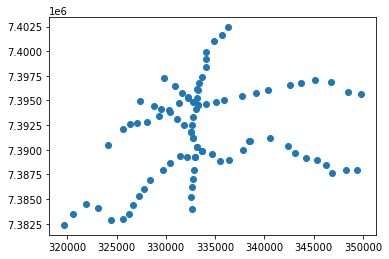

In [44]:
gdf2.plot()

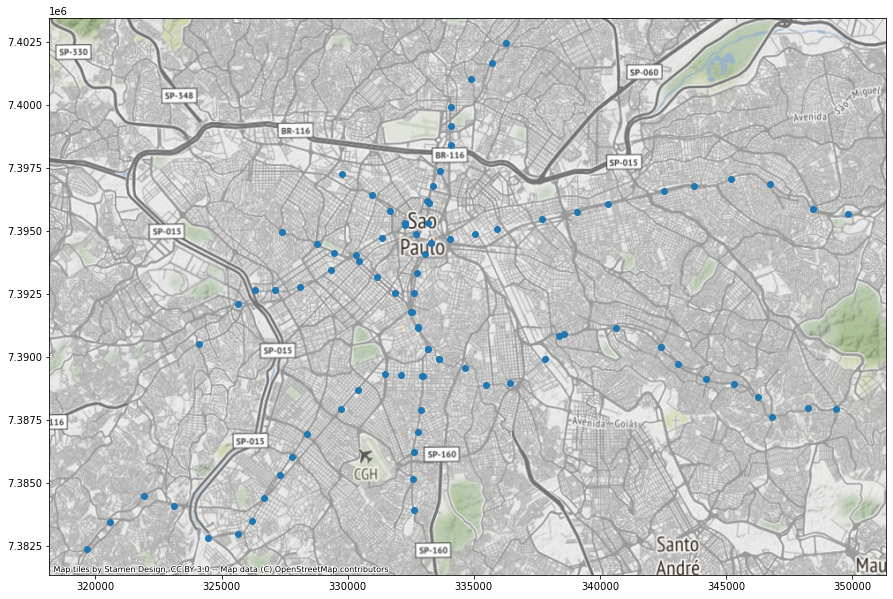

In [45]:
ax = gdf2.plot(figsize=(15, 15), color="None")
gdf2.plot(ax=ax)
cx.add_basemap(ax, crs=gdf2.crs)

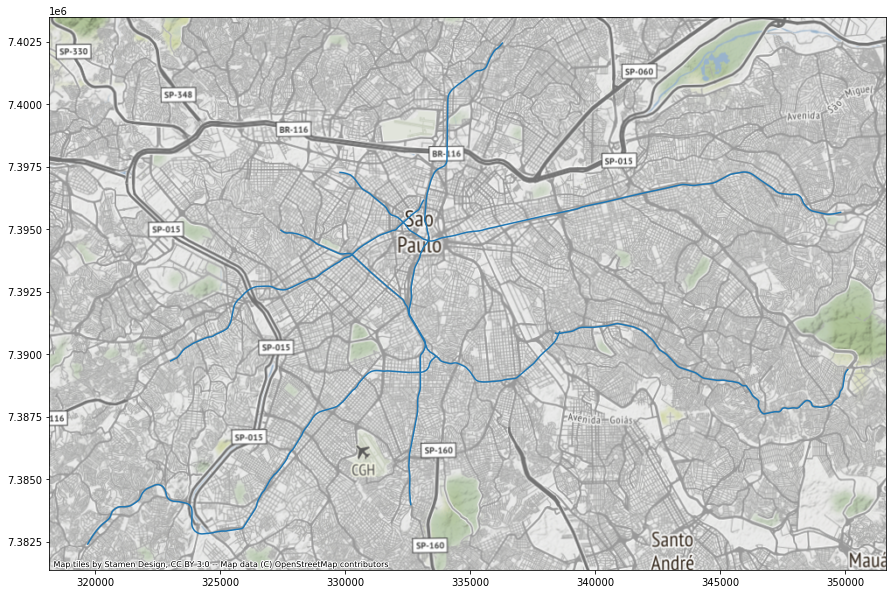

In [46]:
ax = df_lin_subw.plot(figsize=(15, 15), color="None")
df_lin_subw.plot(ax=ax)
cx.add_basemap(ax, crs=df_lin_subw.crs)

In [47]:
lin_sub_buf = df_lin_subw.buffer(500)
est_sub_buf = gdf2.buffer(1000)

In [48]:
est_sub = gpd.GeoDataFrame({'geometry': lin_sub_buf})
lin_sub = gpd.GeoDataFrame({'geometry': est_sub_buf})

In [49]:
est_lin_sub_union = est_sub.union(lin_sub)

C:\Users\sergio\anaconda3\lib\site-packages\geopandas\base.py:31: UserWarning: The indices of the two GeoSeries are different.
  warn("The indices of the two GeoSeries are different.")


In [51]:
est_lin_sub_union = gpd.GeoDataFrame({'geometry': est_lin_sub_union})

In [52]:
est_lin_sub_dissolv = est_lin_sub_union.dissolve()

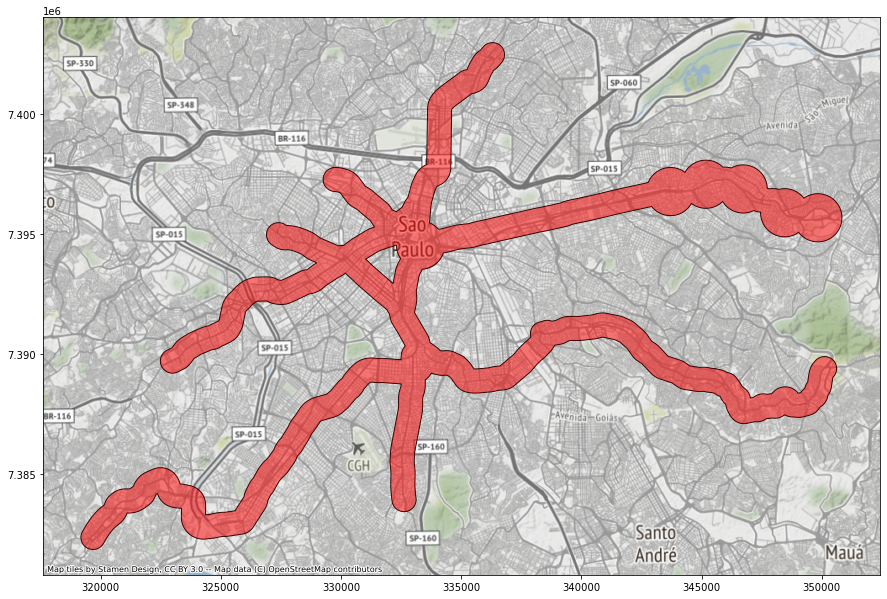

In [53]:
ax = est_lin_sub_dissolv.plot(figsize=(15, 15), edgecolor='black',color="none")

est_lin_sub_dissolv.plot(ax=ax, edgecolor='none', color='red', alpha=0.5)

cx.add_basemap(ax, crs=est_lin_sub_dissolv.crs)

In [54]:
est_lin_sub_dissolv.to_file(r"C:\Users\sergio\Documents\GeoDev\MOD8\Resultados\countries.shp")